
# BIOINF 580 — Lab 2
### 9/23/2026
### GSI: Morgen Henry



---

# 0. Setup Reminder

Before starting this lab, please make sure you are in the correct Python environment.

1. **Activate the conda environment** (in your terminal or Anaconda Prompt):
   ```bash
   conda activate bioinf580
   ```

2. **Select the Jupyter kernel**: when this notebook is open, go to the top-right corner of JupyterLab/Notebook and choose  
   **bioinf580** as the kernel.

3. **Clone the Higuchi Fractal Dimension repo** into the folder where you want to keep it.
   ```bash
   git clone https://github.com/inuritdino/HiguchiFractalDimension.git
   ```

4. **Install the PyWavelets package if you haven’t installed it last time**
   ```bash
   conda install -c conda-forge pywavelets
   ```

5. **Import the required packages**: run the code cell below to load all libraries needed for this lab.

In [1]:
## Import required packages
import os, sys

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from numpy.fft import rfft, rfftfreq
import pywt

# Python needs the folder that CONTAINS the cloned repo on its path (not the repo folder itself).
# If you cloned it next to this notebook, leave this as ".". Otherwise, point it at the parent folder,
# e.g. HFD_PARENT = "~/code" if the repo lives at ~/code/HiguchiFractalDimension
HFD_PARENT = "."
sys.path.insert(0, os.path.abspath(os.path.expanduser(HFD_PARENT)))
import HiguchiFractalDimension as hfd

print("Environment ready — all packages imported.")

Environment ready — all packages imported.


---

# 1. Higuchi Fractal Dimension (HFD)

The **Higuchi Fractal Dimension (HFD)** is a method to estimate the fractal dimension of a 1D time series signal.
  
It measures how “rough” or “complex” a signal is by calculating how the **measured curve length** changes as you zoom in with different scales.

📚 **References**

- **Original method**:  
  Higuchi, T. *Approach to an irregular time series on the basis of the fractal theory*.  
  *Physica D: Nonlinear Phenomena*, 31(2):277–283, 1988.  

- **Python implementation (repo you’re using)**:  
  *HiguchiFractalDimension* (inuritdino), GitHub.  
  https://github.com/inuritdino/HiguchiFractalDimension

## 1.1 Higuchi Fractal Dimension Formula

**For a time series $X(1), X(2), X(3), \dots, X(N)$**:

**Step 1. Subsequence length for offset $m$**:

- For each scale $k$ and offset $m \in \{1,2,\dots,k\}$, the subsequence is:

$$
X(m),\; X(m+k),\; X(m+2k),\; \dots,\; X(m+[\frac{N-m}{k}]k)
$$

- The curve length for that subsequence is:

$$
L_m(k) \;=\; \frac{1}{k}\left[\;
\frac{N-1}{\lfloor (N-m)/k \rfloor \cdot k}
\sum_{i=1}^{\lfloor (N-m)/k \rfloor}
\big|\, X(m+ik) - X(m+(i-1)k)\,\big|
\;\right]
$$

- The factor $\frac{N-1}{\lfloor (N-m)/k \rfloor \cdot k}$ rescales for the fact that the subsequence covers only part of the signal; the leading $\frac{1}{k}$ expresses the length per unit of ruler size. Don't drop it: without it, $L(k)$ scales as $k^{1-D}$ and the fitted slope comes out as $D-1$ instead of $D$.

**Step 2. Average across all offsets**:

- The average curve length for scale $k$ is:

$$
L(k) \;=\; \frac{1}{k} \sum_{m=1}^{k} L_m(k)
$$

- Here the $\frac{1}{k}$ is just the mean over the $k$ offsets. If the signal is fractal, $L(k) \propto k^{-D}$.

**Step 3. Estimate fractal dimension**:

- Plot $\log L(k)$ versus $\log (1/k)$.  

- The slope of the best-fit line is the **Higuchi Fractal Dimension (HFD)**, $D$.

- For 1D time-series signals, the HFD is **bounded between 1 and 2**:  
  - **HFD ≈ 1** → perfectly smooth curve (e.g., straight line).  
  - **HFD → 2** → highly irregular or noisy signal (maximally rough).

## 1.2 Functions & Parameters Used (GitHub Implementation)

This subsection documents the key functions from the `HiguchiFractalDimension` repo that we use in the code block.

### `hfd.hfd(x, opt=True, k_max=None, num_k=50)`
**Purpose:** One-stop computation of the Higuchi Fractal Dimension (HFD) for a 1D signal.

- **`x`** *(array-like, shape = [N])*: The input time series.
- **`opt`** *(bool, default `True`)*: Whether to use the optimized C backend (`libhfd.so`).  
  - The default is `True`, but we have not compiled the C backend, so we **always pass `opt=False` explicitly**. Leaving it at the default will raise an error when the library can't be found.
- **`k_max`** *(int or None, default `None` → N//2)*: The **maximum ruler length (scale)** to consider. Values above N//2 are capped at N//2.
- **`num_k`** *(int, default 50)*: The **number of ruler sizes** (scales) to sample between **2** and `k_max`.  
  - The $k$ values are **logarithmically spaced** (dense at small $k$, sparse at large $k$), then rounded to integers and de-duplicated, so you may get **fewer than `num_k`** values.  
  - More values = more points on the log–log plot, but slower computation.
- **Returns:** *float* — the estimated HFD (theoretical range for 1D curves is **between 1 and 2**).  
  - $ \text{HFD} \approx 1 $ → perfectly smooth curve (e.g., straight line).  
  - $ \text{HFD} \to 2 $ → highly irregular or noisy signal (maximally rough).

**Tips:**  
- Longer signals → more stable estimates.  
- If you see HFD slightly outside [1, 2], adjust `k_max` downward and/or increase `num_k`.

**Examples:** White Noise vs Brownian Motion

- We compare the two classic signals from Higuchi (1988):

  - **White noise (x)**: i.i.d. Gaussian noise → very rough, expected **HFD ≈ 2.0**
  - **Brownian motion (y)**: cumulative sum of Gaussian noise (random walk) → smoother, expected **HFD ≈ 1.5**  




In [2]:
# Reproducibility
rng = np.random.default_rng(0)

# Signals
x = rng.normal(size=10_000)   # white noise
y = np.cumsum(x)              # Brownian motion (random walk)

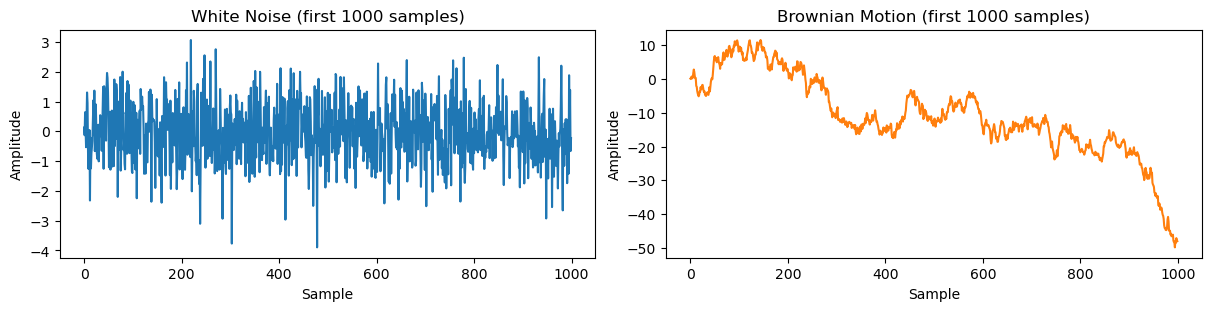

In [3]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 3), constrained_layout=True)

# White noise (first 1000 samples)
axes[0].plot(x[:1000], color="tab:blue")
axes[0].set_title("White Noise (first 1000 samples)")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")

# Brownian motion (first 1000 samples)
axes[1].plot(y[:1000], color="tab:orange")
axes[1].set_title("Brownian Motion (first 1000 samples)")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Amplitude")

plt.show()

In [4]:
# HFD values (convenience)
fd_x = hfd.hfd(x, opt=False)
fd_y = hfd.hfd(y, opt=False)
print(f"HFD (white noise x): {fd_x:.3f}   # ~2.0 expected")
print(f"HFD (Brownian y):   {fd_y:.3f}   # ~1.5 expected")

HFD (white noise x): 1.999   # ~2.0 expected
HFD (Brownian y):   1.481   # ~1.5 expected


### `hfd.curve_length(x, opt=True, k_max=None, num_k=50)`
**Purpose:** Compute Higuchi’s average curve length $L(k)$ at multiple scales.

- **`x`** *(array-like)*: Input time series.
- **`opt`** *(bool)*: Same idea as above.
- **`k_max`** *(int or None)*: Same idea as above.
- **`num_k`** *(int)*: Same idea as above.
- **Returns:**  
  - **k_vals** *(int array, length ≤ `num_k`)*: The $k$ values actually used (after rounding and de-duplication).  
  - **Lk** *(array, same length as `k_vals`)*: The corresponding average lengths $L(k)$.

**Use in our code:** We call this for each signal to obtain $k$ and $L(k)$ so we can draw the log–log plot.

### `hfd.lin_fit_hfd(k_vals, Lk, log=True)`
**Purpose:** Fit a straight line to $\log L(k)$ vs $\log k$ and return the **negative slope = HFD** (equivalent to the slope of $\log L(k)$ vs $\log(1/k)$).

- **`k_vals`** *(array)*: The scale values $k$.
- **`Lk`** *(array)*: The average curve lengths $L(k)$.
- **`log`** *(bool, default `True`)*: Take $\log_2$ of `k_vals` and `Lk` before fitting. Leave this as `True` unless you have already log-transformed them.
- **Returns:** *float* — the fitted slope (HFD).

**Notes:**  
- This function returns **a single float**, not a tuple.  
- The logarithm base does **not** affect the slope (HFD); using *log*, *log10*, or *log2* yields the same result because the base cancels in the slope ratio.

**Example:**


In [5]:
# Curve lengths and slopes (lin_fit_hfd returns a single float)
k_vals,  Lk  = hfd.curve_length(x, opt=False)
slope_x = hfd.lin_fit_hfd(k_vals, Lk)

k_vals2, Lk2 = hfd.curve_length(y, opt=False)
slope_y = hfd.lin_fit_hfd(k_vals2, Lk2)

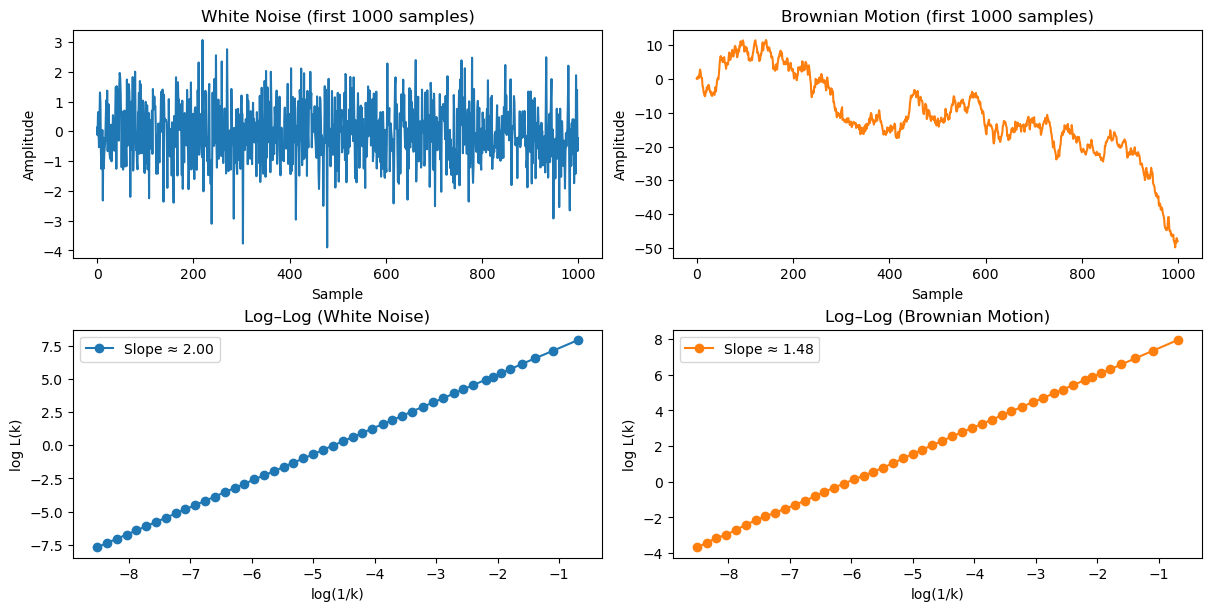

In [6]:
# Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)

# Time series (first 1000 samples)
axes[0,0].plot(x[:1000], color="tab:blue")
axes[0,0].set_title("White Noise (first 1000 samples)")
axes[0,0].set_xlabel("Sample"); axes[0,0].set_ylabel("Amplitude")

axes[0,1].plot(y[:1000], color="tab:orange")
axes[0,1].set_title("Brownian Motion (first 1000 samples)")
axes[0,1].set_xlabel("Sample"); axes[0,1].set_ylabel("Amplitude")

# Log–log plots
axes[1,0].plot(np.log(1/k_vals),  np.log(Lk),  'o-', label=f"Slope ≈ {slope_x:.2f}", color="tab:blue")
axes[1,0].set_title("Log–Log (White Noise)")
axes[1,0].set_xlabel("log(1/k)"); axes[1,0].set_ylabel("log L(k)")
axes[1,0].legend()

axes[1,1].plot(np.log(1/k_vals2), np.log(Lk2), 'o-', label=f"Slope ≈ {slope_y:.2f}", color="tab:orange")
axes[1,1].set_title("Log–Log (Brownian Motion)")
axes[1,1].set_xlabel("log(1/k)"); axes[1,1].set_ylabel("log L(k)")
axes[1,1].legend()

plt.show()

### 1.2.1 Implementing HFD from Scratch

To make sure the formula in 1.1 is not a black box, here is a direct NumPy translation of Steps 1–3. We check it against the library using the **same** $k$ values, so the two answers should agree to floating-point precision.

The last check also shows why `k_max` matters. With the default `k_max = N/2`, the largest rulers (thousands of samples) span a large fraction of a sine's period, the subsequences alias, and the estimate drifts well above 1. Keeping `k_max` small relative to the signal's slowest structure fixes it.

Note the indexing: the formula uses 1-based offsets $m = 1, \dots, k$, while Python uses 0-based indices. `X[m0::k]` with `m0 = m - 1` is exactly the subsequence $X(m), X(m+k), X(m+2k), \dots$


In [7]:
def higuchi_fd(X, k_vals):
    """Higuchi fractal dimension, written directly from the formula in Section 1.1."""
    X = np.asarray(X, dtype=float)
    N = X.size
    Lk = np.empty(len(k_vals))
    for idx, k in enumerate(k_vals):
        Lm = np.empty(k)
        for m0 in range(k):                       # m0 = m - 1 (0-based offset)
            sub = X[m0::k]                        # X(m), X(m+k), X(m+2k), ...
            n_steps = (N - m0 - 1) // k           # floor((N - m) / k)
            norm = (N - 1) / (n_steps * k)        # rescale for partial coverage
            Lm[m0] = np.abs(np.diff(sub)).sum() * norm / k
        Lk[idx] = Lm.mean()                       # (1/k) * sum over m
    slope, intercept = np.polyfit(np.log(1 / np.asarray(k_vals)), np.log(Lk), deg=1)
    return slope, Lk

# Compare with the library on the same k values
D_x, _ = higuchi_fd(x, k_vals)
D_y, _ = higuchi_fd(y, k_vals2)
print(f"White noise   — ours: {D_x:.4f}   library: {slope_x:.4f}")
print(f"Brownian      — ours: {D_y:.4f}   library: {slope_y:.4f}")

# Sanity check at the other end of the range: a smooth sinusoid should give HFD ≈ 1
t_smooth = np.linspace(0, 10, 10_000)
sine = np.sin(2 * np.pi * 0.5 * t_smooth)            # 5 slow cycles over 10,000 samples
D_sine_default, _ = higuchi_fd(sine, k_vals)          # k up to N/2 = 5000
k_small, _ = hfd.curve_length(sine, opt=False, k_max=64)
D_sine_small, _ = higuchi_fd(sine, k_small)
print(f"Smooth sine, k_max = N/2: {D_sine_default:.4f}")
print(f"Smooth sine, k_max = 64:  {D_sine_small:.4f}   (expected ≈ 1.0)")

White noise   — ours: 1.9994   library: 1.9994
Brownian      — ours: 1.4814   library: 1.4814
Smooth sine, k_max = N/2: 1.2687
Smooth sine, k_max = 64:  1.0014   (expected ≈ 1.0)


## 1.3 Features Derived from Higuchi Fractal Dimension (HFD)

The HFD itself is a single complexity measure, but several related features can be extracted to enrich analysis:

1. **Global HFD**  
   - Single fractal dimension value of the entire signal.  
   - Smooth signals → HFD ≈ 1, noisy/irregular signals → HFD ≈ 2.

2. **Time-varying HFD (sliding windows)**  
   - Compute HFD on successive windows of the signal.  
   - Features: mean, variance, min, max, range of HFD across time.  
   - Useful for dynamic signals (e.g. EEG, ECG, gait).

3. **Multi-scale HFD**  
   - Extract HFD using different `k_max` values (different maximum ruler sizes).  
   - Features: short-scale HFD, long-scale HFD, ratio of short/long.  
   - Captures scale-dependent complexity.

4. **Log–log curve features**  
   - The HFD is the slope of $\log L(k)$ vs. $\log(1/k)$.  
   - Additional features:  
     - Slope (HFD)  
     - Intercept  
     <!-- - Goodness of fit ($R^2$)  
     - Curvature or deviations from linearity. -->

5. **Combined nonlinear features**  
   - Combine HFD with other complexity measures:  
     - Entropy (approximate entropy, sample entropy, permutation entropy)  
     <!-- - DFA (detrended fluctuation analysis)  
     - Lyapunov exponents, spectral features   -->
   - Creates a richer feature set for classification or prediction tasks.

**Example: time-varying HFD with sliding windows**

Below, a signal switches from Brownian motion (HFD ≈ 1.5) to white noise (HFD ≈ 2.0) halfway through. A single global HFD would average the two regimes together; a sliding-window HFD shows *when* the change happens. We use a smaller `k_max` here because each window is short (it should stay well below the window length).


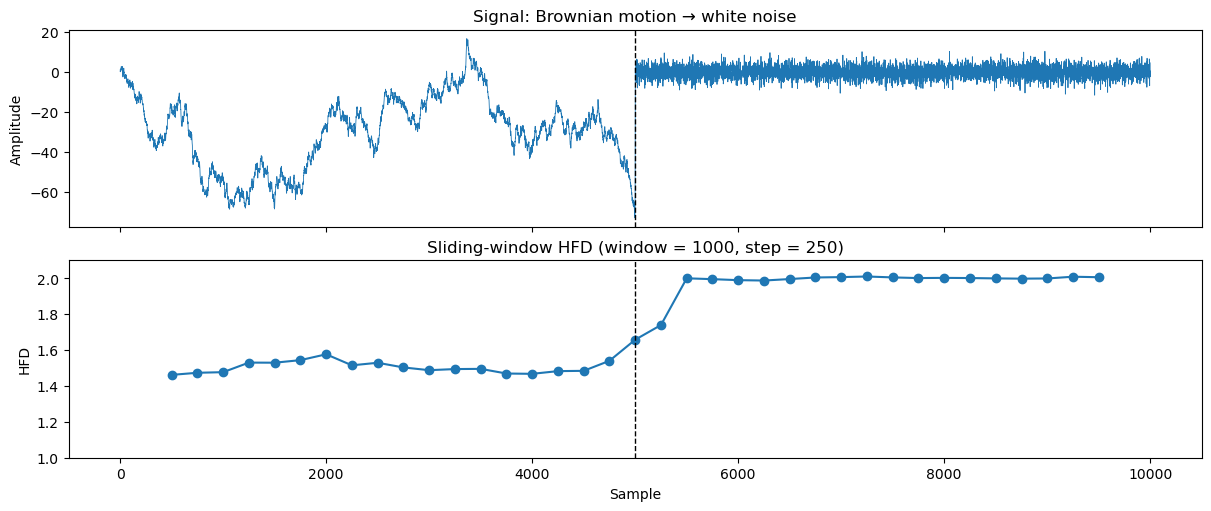

Window-HFD features: mean = 1.743, std = 0.243, min = 1.462, max = 2.011


In [8]:
rng_w = np.random.default_rng(1)
n_half = 5_000
switch_sig = np.concatenate([
    np.cumsum(rng_w.normal(size=n_half)),          # Brownian motion
    rng_w.normal(scale=3, size=n_half),            # white noise
])

win, step = 1_000, 250
starts = np.arange(0, switch_sig.size - win + 1, step)
hfd_t = np.array([hfd.hfd(switch_sig[s:s + win], opt=False, k_max=32) for s in starts])
centers = starts + win // 2

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, constrained_layout=True)
axes[0].plot(switch_sig, lw=0.6)
axes[0].axvline(n_half, color="k", ls="--", lw=1)
axes[0].set_ylabel("Amplitude"); axes[0].set_title("Signal: Brownian motion → white noise")
axes[1].plot(centers, hfd_t, "o-")
axes[1].axvline(n_half, color="k", ls="--", lw=1)
axes[1].set_ylim(1, 2.1)
axes[1].set_xlabel("Sample"); axes[1].set_ylabel("HFD")
axes[1].set_title(f"Sliding-window HFD (window = {win}, step = {step})")
plt.show()

print(f"Window-HFD features: mean = {hfd_t.mean():.3f}, std = {hfd_t.std():.3f}, "
      f"min = {hfd_t.min():.3f}, max = {hfd_t.max():.3f}")

**✏️ Try it**
- Change `win` to 250 and to 3000. How does the transition in the HFD trace change, and why?
- Recompute the global HFD of `y` (Brownian motion) with `k_max` = 8, 64, and the default. Is the estimate stable for this signal?


---

# 2. Wavelet Transform


## 2.1 What are Wavelets?

- A wavelet is a wave-like oscillation with zero average and finite energy, used as a basis for time–frequency analysis.
- It used for analyzing and representing data, particularly for signals and images.
- Key Wavelet Concepts:
    - Scaling: Involves stretching or compressing the wavelet function to capture different frequency components.
    - Shifting: Shifts the wavelet function in time to capture the temporal characteristics of the signal.

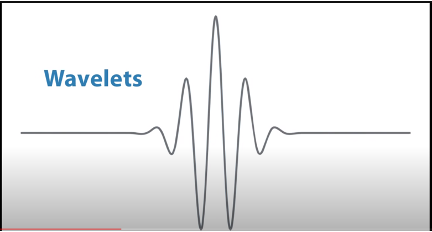 | 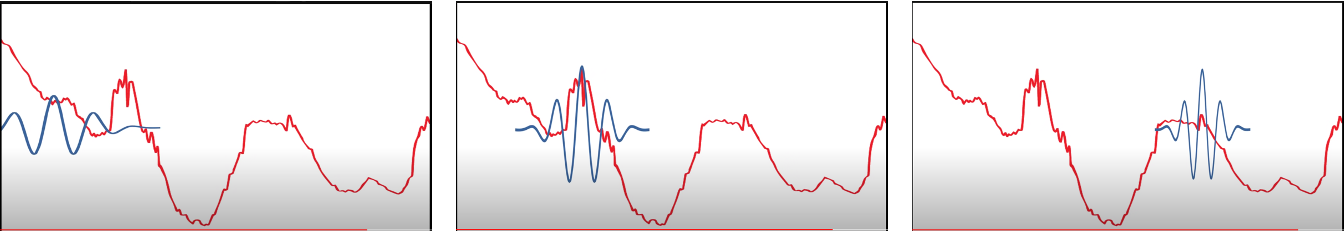
:--:|:--:

📚 **References**

- StatQuest with Josh Starmer. *Wavelet Transforms, Part 1*. YouTube, 2018.  
   [https://www.youtube.com/watch?v=QX1-xGVFqmw&list=PLn8PRpmsu08ojy02wi4QLVzELM545Xw3p&index=2](https://www.youtube.com/watch?v=QX1-xGVFqmw&list=PLn8PRpmsu08ojy02wi4QLVzELM545Xw3p&index=2)

- StatQuest with Josh Starmer. *Wavelet Transforms, Part 2*. YouTube, 2018.  
   [https://www.youtube.com/watch?v=F7Lg-nFYooU&list=PLn8PRpmsu08ojy02wi4QLVzELM545Xw3p&index=3](https://www.youtube.com/watch?v=F7Lg-nFYooU&list=PLn8PRpmsu08ojy02wi4QLVzELM545Xw3p&index=3)


## 2.2 How to choose the Mother Wavelet?

The choice of the **mother wavelet** is crucial — it should resemble the type of patterns in your data.  


**Common Wavelets and Their Applications**

- **Mexican Hat (Ricker) wavelet**  
  - Detects sharp transitions, edges, or spikes.  
  - Symmetric and well localized in time.  
  - **Example**: Applied to **ECG/EEG** to highlight spikes, bursts, or sudden brain wave changes.  
  - 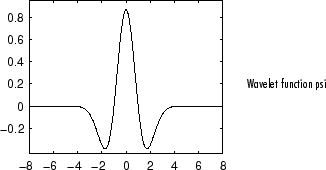

- **Daubechies wavelets**  
  - Compact support, good for analyzing short, transient, non-stationary features.  
  - Many variants (db2, db4, db8, etc.), each balancing smoothness and compactness.  
  - **Example**: Widely used in **biomedical signals** (ECG denoising and QRS detection, EEG sub-band decomposition). (Note: JPEG2000 uses the biorthogonal CDF 9/7 and 5/3 wavelets, not Daubechies.)  
  - 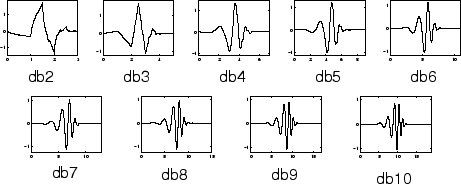

- **Morlet wavelet**  
  - A sinusoid inside a Gaussian envelope, so it matches oscillatory signals well.  
  - Captures both frequency and temporal oscillations well; the complex version (`cmor`) also gives phase.  
  - **Example**: The standard choice for **EEG/MEG time–frequency analysis** (e.g., tracking alpha or gamma power over time); also used in speech and vibration analysis.  
  - 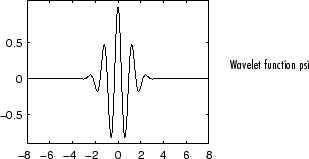

- **Haar wavelet**  
  - Simplest wavelet (step function), ideal for sudden jumps and piecewise constant signals.  
  - Fast and intuitive, though less smooth than others.  
  - **Example**: Used in **image compression** (detecting intensity changes, edges) and **piecewise constant signals**.  
  - 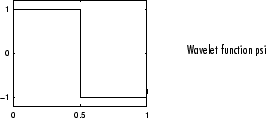


**CWT vs. DWT wavelets in PyWavelets:** Mexican hat (`mexh`) and Morlet (`morl`, `cmor`) are *continuous* wavelets, used with `pywt.cwt`. Daubechies (`db4`, …) and Haar (`haar`) are *discrete* wavelets, used with `pywt.wavedec`. Check with `pywt.wavelist(kind='continuous')` and `pywt.wavelist(kind='discrete')`.

📚 **Reference** 

- [Introduction to the Wavelet Families (MathWorks)](https://www.mathworks.com/help/wavelet/gs/introduction-to-the-wavelet-families.html)


## 2.3 Continuous Wavelet Transform (CWT)

- In simple terms, the Continuous Wavelet Transform is an analysis tool similar to the Fourier Transform, in that it takes a time-domain signal and describes its frequency content.

- However, in contrast to the Fourier Transform, the Continuous Wavelet Transform returns a **two-dimensional result**, providing information in the frequency- as well as in time-domain.

### 2.3.1 Continuous Wavelet Transform (CWT) in PyWavelets:

📚 **Reference** 

- [Continuous Wavelet Transform (CWT)](https://pywavelets.readthedocs.io/en/latest/ref/cwt.html)

#### Function

`pywt.cwt(data, scales, wavelet, sampling_period=1.0)`

#### Parameters

- **`data`**: *1-D array*  
  The input signal to be transformed.

- **`scales`**: *array_like*  
  The set of scales to use in the transform.

- **`wavelet`**: *string or Wavelet object*  
  The mother wavelet to use (e.g. `"cmor"`, `"mexh"`, `"gaus1"`).  
  The choice determines the analyzing waveform.
  To see the list of available continuous wavelets in PyWavelets, you can run: `pywt.wavelist(kind='continuous')`.

- **`sampling_period`**: *float, default=1.0*  
  The spacing between samples in the input signal.  
  For example, if your signal is sampled at 1000 Hz, then `sampling_period = 1/1000`.

#### Returns

- **`coefs`**: *2-D array, shape = [len(scales), len(data)]*  
  The CWT coefficients. Each row corresponds to one scale.  

- **`freqs`**: *1-D array*  
  The frequencies associated with each scale.


### 2.3.2 Understanding the Scale–Frequency Relation and Choosing the Scale Range

When using the Continuous Wavelet Transform (CWT), the transform is defined in terms of **scales** rather than frequencies.  
Scales are inversely related to frequencies:

- **Small scales → High frequencies**.  
- **Large scales → Low frequencies**.

#### How to Choose the Scale Range

**Step 1. Check your sampling rate**  
- Determine your signal’s sampling rate $f_s$ (in Hz).  
- Compute the sampling period, which is the inverse of the sampling rate:  
  `sampling_period = 1 / f_s`  
  - Example: if $f_s = 250$ Hz, then `sampling_period = 1 / 250 = 0.004` seconds.

**Step 2. Decide your frequency band of interest**  
- Choose the range of frequencies you want to analyze.  
   - Example: suppose we want to study 5–50 Hz.  
- Two hard limits:  
   - **Upper limit = Nyquist frequency** $f_s/2$. Scales that map above $f_s/2$ describe frequencies the signal cannot contain; the coefficients there are not meaningful.  
   - **Lower limit set by signal length.** A frequency needs at least a few full cycles inside the recording (e.g., a 2-second recording can't say much about 0.5 Hz). Low-frequency coefficients near the edges of the signal are also distorted by boundary effects (the "cone of influence").

**Step 3. Convert the frequency band into scales**  
- The relation between scale and frequency is:  
  $$\text{scale} = \frac{\text{mother wavelet's center\_frequency}}{\text{frequency of interest} \times \text{sampling\_period}}$$
- To get the mother wavelet’s center frequency in PyWavelets, use `pywt.central_frequency('[wavelet name]')`. It differs between wavelets:  
   - Real Morlet `'morl'` → 0.8125; Mexican hat `'mexh'` → 0.25  
   - Complex Morlet `'cmorB-C'` → **C** (e.g. `'cmor1.5-1.0'` → 1.0). Always give B and C explicitly; plain `'cmor'` triggers a warning and falls back to defaults.  
   - Example using the **real Morlet wavelet** (`pywt.central_frequency('morl')` ≈ 0.8125):  
      - For 50 Hz:  
         $\text{scale} \approx \tfrac{0.8125}{50 \times 0.004} \approx 4.06$  
      - For 5 Hz:  
         $\text{scale} \approx \tfrac{0.8125}{5 \times 0.004} \approx 40.6$  
   - So the scale range is approximately **[4, 41]**.  

**Step 4. Choose scale spacing**
- Because frequency ∝ 1/scale, the spacing you choose for **scales** is not the spacing you get in **frequency**:  
   - **Log-spaced scales** (`np.geomspace`) ⇔ **log-spaced frequencies** (equal ratios). This is the usual choice.  
   - **Linearly spaced scales** (`np.arange`) do *not* give linearly spaced frequencies. They pile up points at low frequencies and leave big gaps at high frequencies.  
   - If you want a specific frequency grid, the simplest approach is to build the grid in **frequency** and convert it to scales with `pywt.frequency2scale` (see the CWT example below).  
   - **Why log spacing? Notes (spacing shown in frequency):**
      - Many signals vary **octavely** (e.g., 1–2 Hz, 2–4 Hz, 4–8 Hz, …).  
         This means important changes happen in frequency *ratios* (doublings), not equal differences.  

      - **Linear spacing** uses equal differences, so it misses detail at low frequencies and overrepresents high frequencies.  
         - Example (1–128 Hz, 10 points linearly spaced):  
            1.0, 15.1, 29.2, 43.3, 57.4, 71.6, 85.7, 99.8, 113.9, 128.0  
            → Very few points represent the lowest octaves (1–8 Hz), while many points fall above 50 Hz.  

      - **Logarithmic spacing** uses equal ratios, so each octave (1–2, 2–4, 4–8, …, 64–128) gets the same number of points.  
         - Example (1–128 Hz, 10 points log-spaced):  
            1.0, 1.7, 2.9, 5.0, 8.6, 14.8, 25.4, 43.5, 74.7, 128.0  
            → The lower bands (1–10 Hz) get five points, and every octave gets roughly the same share.  

      - ✅ **Conclusion**: Log spacing aligns with octave-like changes in real signals and captures information evenly across scales, while linear spacing distorts the resolution by under-sampling low frequencies and over-sampling high frequencies.


In [9]:
# --- Define wavelet and sampling information ---
wavelet = pywt.ContinuousWavelet('cmor1.5-1.0')  # complex Morlet, bandwidth B=1.5, center frequency C=1.0
sampling_period = 0.001                         # 1 kHz sampling rate
print("Center frequency:", pywt.central_frequency(wavelet))

# --- Example 1: Convert frequency to scale ---
# pywt.frequency2scale expects a *normalized* frequency (cycles per sample) = freq_Hz * sampling_period
target_freq = 10  # Hz
scale = pywt.frequency2scale(wavelet, target_freq * sampling_period)

print(f"Scale corresponding to {target_freq} Hz: {scale:.3f}")

Center frequency: 1.0
Scale corresponding to 10 Hz: 100.000


In [10]:
# --- Example 2: Convert scale to frequency ---
# pywt.scale2frequency returns cycles per sample; divide by sampling_period to get Hz
example_scale = 50
freq = pywt.scale2frequency(wavelet, example_scale) / sampling_period

print(f"Frequency corresponding to scale {example_scale}: {freq:.3f} Hz")

Frequency corresponding to scale 50: 20.000 Hz


In [11]:
# --- Example 3: Generate full mapping between scales and frequencies ---
scales = np.geomspace(1, 1024, num=20)
freqs = pywt.scale2frequency(wavelet, scales) / sampling_period
nyquist = 1 / (2 * sampling_period)

print(f"Scale–Frequency mapping (Nyquist = {nyquist:.0f} Hz):")
for s, f in zip(scales, freqs):
    flag = "  ← above Nyquist, not meaningful" if f > nyquist else ""
    print(f"Scale {s:8.2f}  →  Frequency {f:8.2f} Hz{flag}")

# Smallest usable scale for this wavelet: the one that maps exactly to Nyquist
print(f"\nSmallest meaningful scale ≈ {pywt.frequency2scale(wavelet, 0.5):.2f}")

Scale–Frequency mapping (Nyquist = 500 Hz):
Scale     1.00  →  Frequency  1000.00 Hz  ← above Nyquist, not meaningful
Scale     1.44  →  Frequency   694.33 Hz  ← above Nyquist, not meaningful
Scale     2.07  →  Frequency   482.09 Hz
Scale     2.99  →  Frequency   334.73 Hz
Scale     4.30  →  Frequency   232.41 Hz
Scale     6.20  →  Frequency   161.37 Hz
Scale     8.93  →  Frequency   112.04 Hz
Scale    12.85  →  Frequency    77.79 Hz
Scale    18.51  →  Frequency    54.01 Hz
Scale    26.66  →  Frequency    37.50 Hz
Scale    38.40  →  Frequency    26.04 Hz
Scale    55.31  →  Frequency    18.08 Hz
Scale    79.66  →  Frequency    12.55 Hz
Scale   114.73  →  Frequency     8.72 Hz
Scale   165.24  →  Frequency     6.05 Hz
Scale   237.99  →  Frequency     4.20 Hz
Scale   342.76  →  Frequency     2.92 Hz
Scale   493.66  →  Frequency     2.03 Hz
Scale   710.99  →  Frequency     1.41 Hz
Scale  1024.00  →  Frequency     0.98 Hz

Smallest meaningful scale ≈ 2.00


### 2.3.3 Example of the Continuous Wavelet Transform (CWT)

First, we generate an artificial signal to be analyzed: the sum of two sine waves whose frequency increases over time (“chirps”). For reference, we also plot the two time-dependent frequency components it contains.

⚠️ **A subtle point about chirps.** It is tempting to write a chirp as $\sin(2\pi f(t)\,t)$, but the instantaneous frequency of $\sin(\phi(t))$ is $\frac{1}{2\pi}\frac{d\phi}{dt}$, which for $\phi = 2\pi f(t)\,t$ is $f(t) + t\,f'(t)$, **not** $f(t)$. (The PyWavelets documentation example makes this mistake; with $f(t)=(a(t+t_0))^2$ the true frequency ends up ~2.7× higher than intended by $t = 1$.) The correct construction integrates the frequency to get the phase:

$$\phi(t) = 2\pi \int_0^t f(\tau)\,d\tau$$

For $f(t) = (a(t+t_0))^2$ this integral is $\frac{a^2}{3}\left[(t+t_0)^3 - t_0^3\right]$, which is what `make_chirp` uses below.

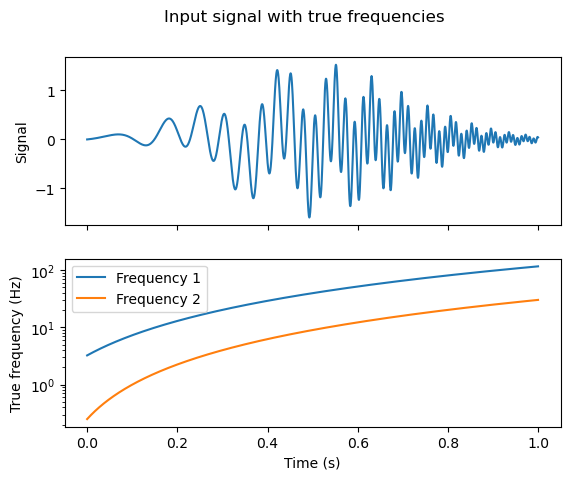

In [12]:
# --- helper functions ---
def gaussian(x, x0, sigma):
    return np.exp(-np.power((x - x0) / sigma, 2.0) / 2.0)

def make_chirp(t, t0, a):
    """Chirp whose instantaneous frequency is exactly f(t) = (a*(t + t0))**2."""
    frequency = (a * (t + t0)) ** 2
    phase = 2 * np.pi * (a ** 2) * ((t + t0) ** 3 - t0 ** 3) / 3   # 2π ∫ f dt
    return np.sin(phase), frequency

# --- generate signal ---
fs = 2000                                  # sampling rate (Hz)
time = np.arange(0, 1, 1 / fs)             # 1 s, 2000 samples
chirp1, frequency1 = make_chirp(time, 0.2, 9)
chirp2, frequency2 = make_chirp(time, 0.1, 5)
chirp = chirp1 + 0.6 * chirp2
chirp *= gaussian(time, 0.5, 0.2)          # apply Gaussian window

# --- plot signal and true frequencies ---
fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].plot(time, chirp)
axs[1].plot(time, frequency1, label="Frequency 1")
axs[1].plot(time, frequency2, label="Frequency 2")
axs[1].set_yscale("log")
axs[1].set_xlabel("Time (s)")
axs[0].set_ylabel("Signal")
axs[1].set_ylabel("True frequency (Hz)")
axs[1].legend()
plt.suptitle("Input signal with true frequencies")
plt.show()

We then apply the Continuous Wavelet Transform using a complex Morlet wavelet with a given bandwidth and center frequency (`cmor1.5-1.0`). Following Section 2.3.2, we build a log-spaced **frequency** grid from 2 Hz up to the Nyquist frequency, convert it to scales, and plot the so-called “scalogram”: the magnitude of the coefficients vs. time and frequency. The true frequencies are overlaid as dashed lines so you can check the result.

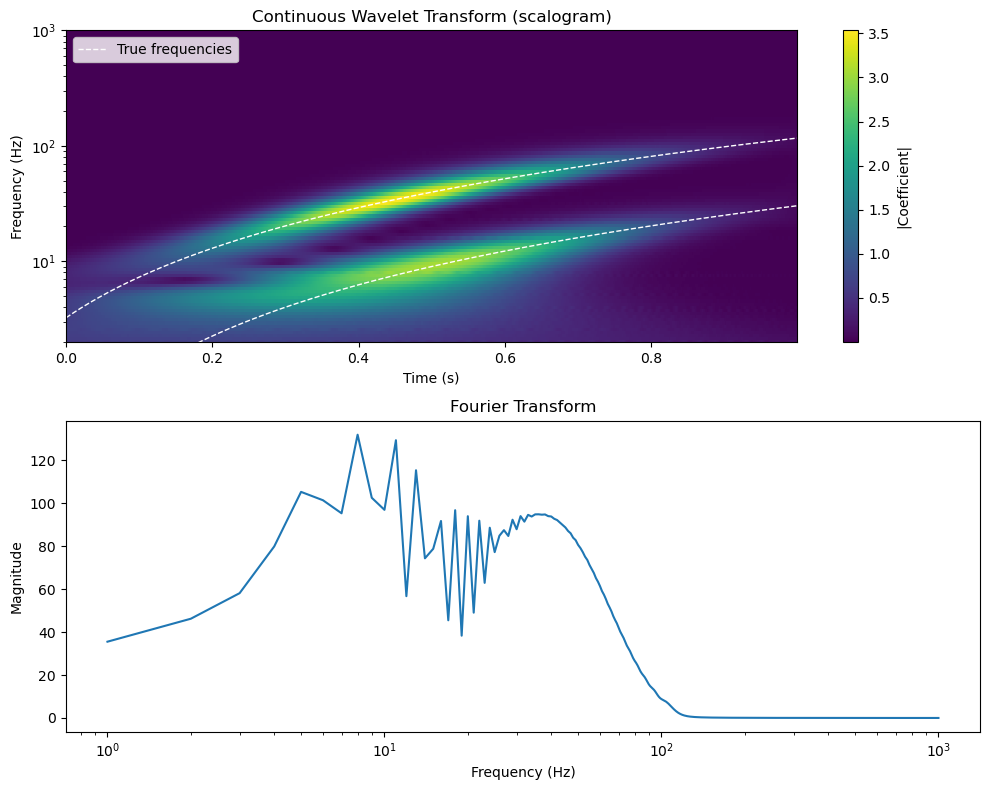

In [13]:
# --- perform CWT ---
wavelet = "cmor1.5-1.0"
sampling_period = 1 / fs

# Log-spaced frequency grid (2 Hz → Nyquist), converted to scales
target_freqs = np.geomspace(2, fs / 2, num=100)
scales = pywt.frequency2scale(wavelet, target_freqs * sampling_period)

cwtmatr, freqs = pywt.cwt(chirp, scales, wavelet, sampling_period=sampling_period)
cwtmatr = np.abs(cwtmatr)   # take magnitude (complex result)

# --- plot scalogram ---
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
pcm = axs[0].pcolormesh(time, freqs, cwtmatr, shading="auto")
axs[0].plot(time, frequency1, "w--", lw=1, label="True frequencies")
axs[0].plot(time, frequency2, "w--", lw=1)
axs[0].set_yscale("log")
axs[0].set_ylim(freqs.min(), freqs.max())
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Frequency (Hz)")
axs[0].set_title("Continuous Wavelet Transform (scalogram)")
axs[0].legend(loc="upper left")
fig.colorbar(pcm, ax=axs[0], label="|Coefficient|")

# --- Fourier Transform for comparison ---
yf = rfft(chirp)
xf = rfftfreq(len(chirp), sampling_period)
axs[1].semilogx(xf[1:], np.abs(yf[1:]))    # skip the 0 Hz bin on a log axis
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_title("Fourier Transform")
axs[1].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

The CWT resolves the two frequency components clearly and tracks how each one rises over time; the bright ridges sit on the dashed lines. The Fourier Transform shows *which* frequencies are present but not *when*: each chirp is smeared into a broad band. Note also how the high-frequency ridge is sharp in time but broad in frequency, while the low-frequency ridge is the opposite. That is the wavelet time–frequency trade-off at work.

**✏️ Try it**
- Reverse the signal (`chirp[::-1]`) and recompute the scalogram. What changes, and what does the Fourier magnitude spectrum do?
- Change the wavelet to `cmor0.5-1.0` and `cmor5.0-1.0`. How does the bandwidth parameter B trade time resolution for frequency resolution?

### 2.3.4 Features Derived from the Continuous Wavelet Transform (CWT)

Once the CWT coefficients are computed, various quantitative features can be extracted.  
These features summarize time–frequency information and are useful for classification, clustering, or statistical analysis of signals.

##### 1. Energy-related Features
- **Total energy**: sum of squared magnitudes of CWT coefficients.  
- **Band energy**: energy restricted to specific frequency bands (e.g., delta, theta, alpha, beta in EEG).  
- **Relative energy distribution**: proportion of total energy contributed by each band.

##### 2. Time–Frequency Localization
- **Instantaneous dominant frequency**: frequency with the highest energy at each time.  
<!-- - **Ridge extraction**: track the path of maximum coefficients across time to follow oscillatory modes.   -->
- **Duration of transients**: measure how long a burst or oscillation lasts at a given scale.

##### 3. Statistical Descriptors
- **Mean / variance of coefficients**: per scale or per time window.  
- **Skewness / kurtosis**: distributional shape of coefficients.  
- **Entropy measures**: wavelet entropy quantifies signal complexity or irregularity.  
- **Fractal / scaling features**: characterize self-similarity across scales.


low (5–30 Hz)      relative energy = 0.441
mid (30–70 Hz)     relative energy = 0.497
high (70–150 Hz)   relative energy = 0.062


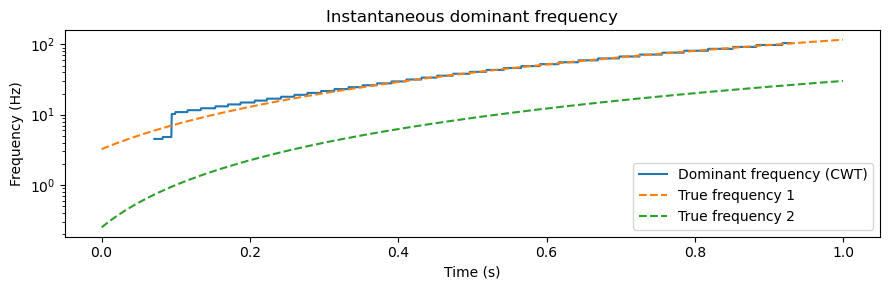

In [14]:
# --- Example CWT features from the scalogram above ---
# PyWavelets' CWT magnitude for a pure sinusoid grows with sqrt(scale), which inflates low frequencies.
# Dividing the power by the scale puts all frequencies on an equal footing before comparing them.
power = cwtmatr ** 2 / scales[:, None]                  # shape: (n_freqs, n_times)

bands = {"low (5–30 Hz)": (5, 30), "mid (30–70 Hz)": (30, 70), "high (70–150 Hz)": (70, 150)}
band_energy = {name: power[(freqs >= lo) & (freqs < hi)].sum() for name, (lo, hi) in bands.items()}
total = sum(band_energy.values())
for name, e in band_energy.items():
    print(f"{name:18s} relative energy = {e / total:.3f}")

# Instantaneous dominant frequency: frequency with the most power at each time point
dominant_freq = freqs[power.argmax(axis=0)]
active = gaussian(time, 0.5, 0.2) > 0.1                 # ignore the near-silent edges
plt.figure(figsize=(9, 3))
plt.plot(time[active], dominant_freq[active], label="Dominant frequency (CWT)")
plt.plot(time, frequency1, "--", label="True frequency 1")
plt.plot(time, frequency2, "--", label="True frequency 2")
plt.yscale("log"); plt.xlabel("Time (s)"); plt.ylabel("Frequency (Hz)")
plt.title("Instantaneous dominant frequency"); plt.legend()
plt.tight_layout(); plt.show()

# Lab Takeaways:

**Scope (Lab):** You explored two pillars of 1D signal analysis:

1) **Fractal Dimension (Higuchi)**  
   - *Idea:* quantified geometric roughness/complexity (FD ∈ [1, 2]).  
   - *You learned:* how to compute HFD with the library, implement it from scratch, verify it on smooth vs. noisy signals, and track it over time with sliding windows.  
   - **Feature ideas (you used or can extend):**  
     - FD (single scalar per segment)  
     - FD vs. different $k_{\max}$ (stability curve) 

2) **Continuous Wavelet Transform (CWT)**  
   - *Idea:* produced a time–frequency map with adaptive resolution via scaled/shifted mother wavelets.  
   - *You learned:* to choose a frequency range, map to scales, compute CWT, and interpret scalograms.  
   - **Feature ideas:**  
     - Band energies from scalograms (e.g., 1–4, 4–12, 12–30 Hz)  
     - Temporal stats per band (mean, max, variance, burst count)
---